In [2]:
from ipywidgets import interact
import matplotlib.pyplot as plt

In [3]:
from iScat_particle_analysis import TrackSettings, locate_single_frame



locate = {
    "locate_invert_frame" : True,
    "locate_frame_index" : 0,
    "locate_micron_per_pixel" : 0.09,  # um
    "locate_half_width_gaussian" : 0.520/2 ,  #um
    "locate_value_threshold" : 0,
    "locate_minmass" : 1.3,
    "locate_maxsize" : 100,  
}

link = {    
    "link_search_range" : 10,    # default 10
    "link_frame_memory" : 50,   # default 150
    "link_strategy" : "auto"
}

annotate = {
    "markersize" : 25, 
    "markeredgewidth" : 0,
    "markerfacecolor" : "k", 
    "markeredgecolor" : "none",
    "marker" : ".",
    "dpi" : 20
}

tracking_settings = TrackSettings(
    locate=locate,
    link=link,
    annotate=annotate
)


fullpath = "/Users/giovannideangelis/Documents/PhD/Code/Tracking/Stacks/20240617_POPC_CHOL_11/POPCCH11_DSPEpeg_40nmGNP_rec_iSCAT_1.tif"
FileName = "TEST"
true_radius = tracking_settings.locate["locate_true_radius"]

print(f"Currently tracking the following data: {fullpath}")
print(f"Current diameter is {true_radius} pixels")

Currently tracking the following data: /Users/giovannideangelis/Documents/PhD/Code/Tracking/Stacks/20240617_POPC_CHOL_11/POPCCH11_DSPEpeg_40nmGNP_rec_iSCAT_1.tif
Current diameter is 7 pixels


/opt/homebrew/Caskroom/miniconda/base/envs/iscatTracking/lib/python3.9/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
tracking_settings.locate['locate_true_radius'] += 2   # default 4 
true_radius = tracking_settings.locate["locate_true_radius"]
print(f"Current diameter is {true_radius} pixels")

Current diameter is 9 pixels


In [5]:
import tifffile as tiff

video_path = fullpath
video = tiff.imread(video_path)

In [6]:
@interact(frame_index = (0, len(video) - 1))
def single_annotation(frame_index = 0):
    tracking_settings.locate["locate_frame_index"] = frame_index
    locate_single_frame(video, tracking_settings)

interactive(children=(IntSlider(value=0, description='frame_index', max=2999), Output()), _dom_classes=('widge…

In [7]:
import trackpy as tp

df = tp.batch(video,
    invert=tracking_settings.locate["locate_invert_frame"],
    diameter=tracking_settings.locate["locate_true_radius"],
    minmass=tracking_settings.locate["locate_minmass"], 
    maxsize=tracking_settings.locate["locate_maxsize"],
    #after_locate=convert_to_micron
)


Frame 2999: 4 features


In [8]:
import numpy as np
tmp = df["frame"].drop_duplicates(keep=False)    #duplicates
tmp

16         7
39        18
40        19
43        21
44        22
        ... 
4993    2982
4996    2984
4997    2985
4998    2986
5013    2993
Name: frame, Length: 908, dtype: int64

In [9]:
linked_df = tp.link(df,
    search_range=tracking_settings.link["link_search_range"],
    memory=tracking_settings.link["link_frame_memory"],
    link_strategy=tracking_settings.link["link_strategy"]
)

Frame 2999: 4 trajectories present.


In [10]:
ids = list(linked_df["particle"].unique())
print(f"[PRE-FILTER] Track IDs: {ids}")
for id in ids:
    length = len(linked_df[linked_df["particle"] == id])
    print(f"[PRE-FILTER] Track {id} length: {length}")

[PRE-FILTER] Track IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
[PRE-FILTER] Track 0 length: 3
[PRE-FILTER] Track 1 length: 64
[PRE-FILTER] Track 2 length: 1
[PRE-FILTER] Track 3 length: 76
[PRE-FILTER] Track 4 length: 19
[PRE-FILTER] Track 5 length: 10
[PRE-FILTER] Track 6 length: 10
[PRE-FILTER] Track 7 

In [11]:
filtered_linked_df = tp.filter_stubs(linked_df, threshold=1000)  # TO FILTER OUT SHORT TRACKS

ids = list(filtered_linked_df["particle"].unique())
print(f"[POST-FILTER] Track IDs: {ids}")
for id in ids:
    length = len(filtered_linked_df[filtered_linked_df["particle"] == id])
    print(f"[POST-FILTER] Track {id} length: {length}")

[POST-FILTER] Track IDs: [np.int64(14)]
[POST-FILTER] Track 14 length: 1878


In [12]:
import numpy as np
tmp = filtered_linked_df["frame"].drop_duplicates(keep=False)    #duplicates
tmp

frame
477      477
479      479
481      481
483      483
484      484
        ... 
2806    2806
2807    2807
2810    2810
2811    2811
2815    2815
Name: frame, Length: 1878, dtype: int64

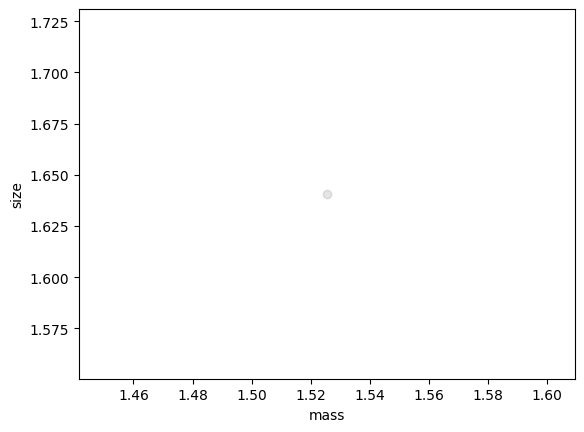

In [13]:
plt.figure()
tp.mass_size(filtered_linked_df.groupby('particle').mean()); # convenience function -- just plots size vs. mass

/opt/homebrew/Caskroom/miniconda/base/envs/iscatTracking/lib/python3.9/site-packages/trackpy/plots.py:361: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  coords = unstacked.bfill().stack().loc[first_frame]


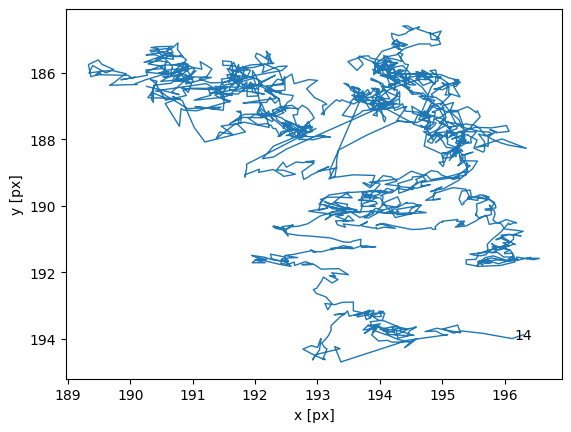

In [14]:
import matplotlib.pyplot as plt

# plt.rcParams["text.usetex"] = True
# we already converted to microns in tp.batch
# using the convert_to_micron function
# setting mpp=1 is just to force the labels
# to be in micrometer scale
tp.plot_traj(filtered_linked_df, label=True) # (mpp = 1, default )
plt.rcParams["text.usetex"] = False

In [20]:
filtered_linked_df = filtered_linked_df.drop(["mass", "size", "ecc", "signal", "raw_mass", "ep"], axis=1)

In [21]:
filtered_linked_df.to_csv(f"./Tracks/{FileName}_tracks.csv", columns=filtered_linked_df.columns)